# K-Means clustering
Neste notebook vamos explorar o uso de K-Means para agrupar funcionários com base em variáveis relevantes.
Passos: EDA -> Pré-processamento -> Elbow & Silhouette -> Treinamento final -> Análise dos clusters.

In [1]:
# Imports básicos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
sns.set(style='whitegrid')
RANDOM_STATE = 42

In [2]:
# Carregar dados
df = pd.read_csv('funcionarios.csv')
df.shape
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## 1) EDA rápido
Verificar distribuições e variáveis candidatas para clustering.

(1470, 35)
                           count          mean          std     min      25%  \
Age                       1470.0     36.923810     9.135373    18.0    30.00   
DailyRate                 1470.0    802.485714   403.509100   102.0   465.00   
DistanceFromHome          1470.0      9.192517     8.106864     1.0     2.00   
Education                 1470.0      2.912925     1.024165     1.0     2.00   
EmployeeCount             1470.0      1.000000     0.000000     1.0     1.00   
EmployeeNumber            1470.0   1024.865306   602.024335     1.0   491.25   
EnvironmentSatisfaction   1470.0      2.721769     1.093082     1.0     2.00   
HourlyRate                1470.0     65.891156    20.329428    30.0    48.00   
JobInvolvement            1470.0      2.729932     0.711561     1.0     2.00   
JobLevel                  1470.0      2.063946     1.106940     1.0     1.00   
JobSatisfaction           1470.0      2.728571     1.102846     1.0     2.00   
MonthlyIncome             147

C:\Users\gustavo.telles\AppData\Local\Temp\ipykernel_17028\342873187.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df, palette='Set2')


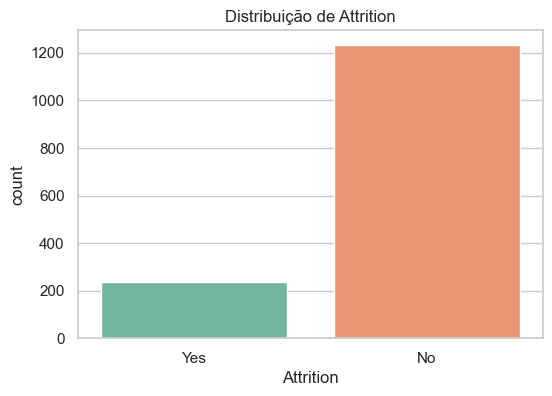

In [3]:
# Distribuição do alvo e estatísticas básicas
print(df.shape)
print(df.describe().T)
plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df, palette='Set2')
plt.title('Distribuição de Attrition')
plt.savefig('imagens/attrition_distribution.png')
plt.show()

## 2) Pré-processamento mínimo
Selecionar variáveis numéricas, imputar (se necessário) e escalar antes do KMeans.

In [4]:
# Selecionar colunas numéricas para clustering (exclua identificadores)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for c in ['EmployeeNumber','EmployeeCount','StandardHours']:
    if c in num_cols: num_cols.remove(c)
X = df[num_cols].copy()
# Imputar valores se necessário (simplesmente preencher com mediana)
X = X.fillna(X.median())
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Shape X_scaled:', X_scaled.shape)

Shape X_scaled: (1470, 23)


## 3) PCA para visualização
Reduzir para 2 componentes para facilitar plotagem dos clusters propostas.

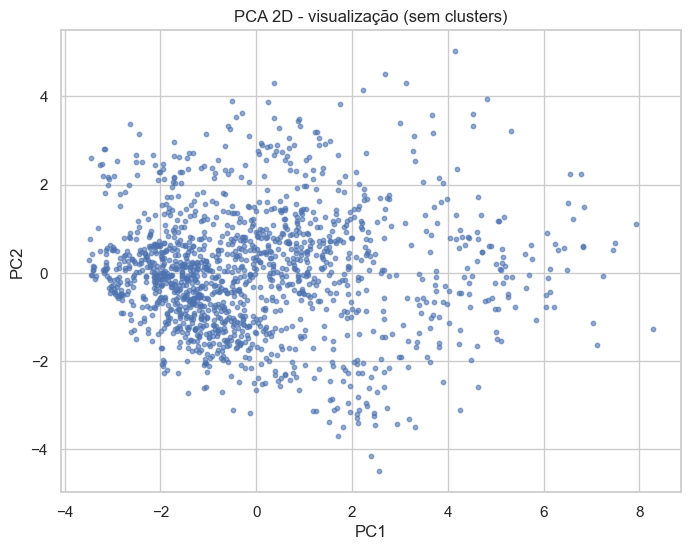

In [5]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], s=10, alpha=0.6)
plt.title('PCA 2D - visualização (sem clusters)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.savefig('imagens/pca_2d.png')
plt.show()

## 4) Escolha de K: Elbow e Silhouette

Vamos calcular inertia (elbow) e silhouette score para K entre 2 e 10 para escolher um bom número de clusters.

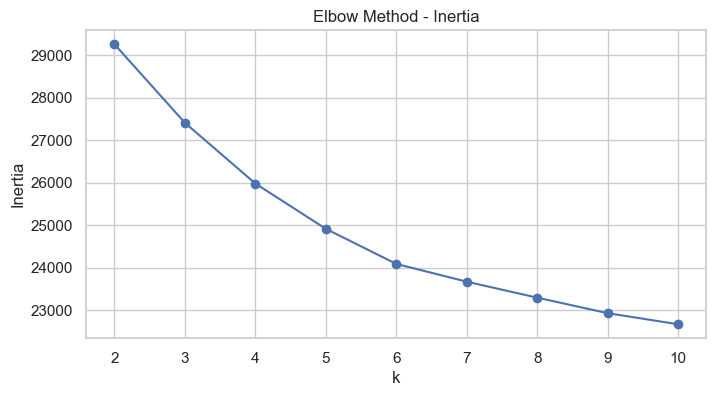

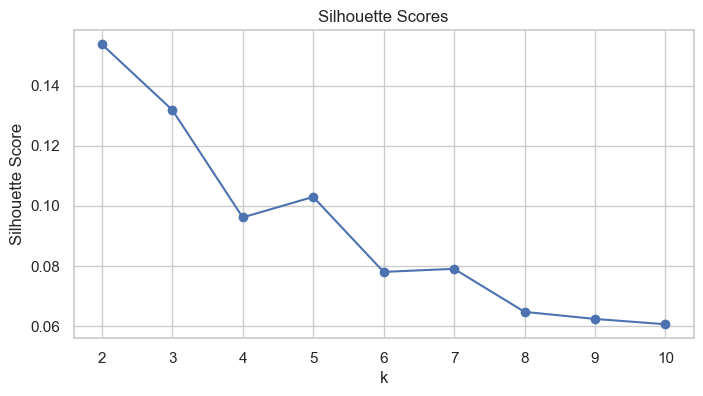

Inertias: [29253.476334573057, 27407.51878556957, 25979.556415014922, 24915.101388204836, 24089.73245564896, 23671.70167076535, 23296.420290835646, 22931.68976083189, 22670.96464652896]
Silhouettes: [0.15380376471271287, 0.1319519397265848, 0.09617375287005198, 0.10299849825591245, 0.07803591223641337, 0.079053971888407, 0.06473388062241028, 0.06237582259804972, 0.06060898526689358]


In [6]:
from sklearn.cluster import KMeans
inertias = []
silhouettes = []
K_range = range(2,11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    try:
        silhouettes.append(silhouette_score(X_scaled, labels))
    except Exception:
        silhouettes.append(np.nan)
# Plot Inertia (Elbow)
plt.figure(figsize=(8,4))
plt.plot(list(K_range), inertias, '-o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method - Inertia')
plt.grid(True)
plt.savefig('imagens/kmeans_elbow.png', bbox_inches='tight', dpi=150)
plt.show()
# Plot Silhouette
plt.figure(figsize=(8,4))
plt.plot(list(K_range), silhouettes, '-o')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.grid(True)
plt.savefig('imagens/kmeans_silhouette.png', bbox_inches='tight', dpi=150)
plt.show()
print('Inertias:', inertias)
print('Silhouettes:', silhouettes)

## 5) Treinar KMeans final e salvar artefatos

Treinar KMeans com k=2 (baseado nas métricas anteriores) e salvar arquivos para análise posterior.

In [8]:
import joblib

K_FINAL = 2
km_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
labels_final = km_final.fit_predict(X_scaled)

# Salvar labels e X processado
out_root = r"C:\Users\gustavo.telles\Documents\GitHub\machine-learning-grupo4\docs\kmeans"
pd.DataFrame(labels_final, columns=['cluster']).to_csv(out_root + r"\\kmeans_clusters.csv", index=False)
pd.DataFrame(X, columns=num_cols).to_csv(out_root + r"\\kmeans_X.csv", index=False)

# Salvar modelo
joblib.dump(km_final, out_root + r"\\kmeans_model.joblib")

# Plot clusters em PCA 2D
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=labels_final, cmap='tab10', s=10)
plt.title(f'KMeans clusters (k={K_FINAL}) - PCA 2D')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(scatter, ticks=range(K_FINAL))
cluster_path = out_root + r"\\imagens\\kmeans_clusters.png"
plt.savefig(cluster_path, bbox_inches='tight', dpi=150)
plt.close()

print('Saved clusters:', out_root + r"\\kmeans_clusters.csv")
print('Saved X:', out_root + r"\\kmeans_X.csv")
print('Saved model:', out_root + r"\\kmeans_model.joblib")
print('Saved plot:', cluster_path)

Saved clusters: C:\Users\gustavo.telles\Documents\GitHub\machine-learning-grupo4\docs\kmeans\\kmeans_clusters.csv
Saved X: C:\Users\gustavo.telles\Documents\GitHub\machine-learning-grupo4\docs\kmeans\\kmeans_X.csv
Saved model: C:\Users\gustavo.telles\Documents\GitHub\machine-learning-grupo4\docs\kmeans\\kmeans_model.joblib
Saved plot: C:\Users\gustavo.telles\Documents\GitHub\machine-learning-grupo4\docs\kmeans\\imagens\\kmeans_clusters.png
